### Principal Concepts:
Overfit, underfit.

Stratify = True

Balanced datasets vs unbalanced datasets

drop_first = True

In [115]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

df = sns.load_dataset("titanic")
df.head()

df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
df.to_csv("titanic.csv", index=False)

df = df[df['age'].notnull()]

df['age'] = df['age'].fillna(df['age'].median())
df = pd.get_dummies(df, columns=['sex'], drop_first=True, dtype=float) 
df.head()

,survived,pclass,age,sibsp,parch,fare,sex_male
0,0,3,22.0,1,0,7.2500,1.0
1,1,1,38.0,1,0,71.2833,0.0
2,1,3,26.0,0,0,7.9250,0.0
3,1,1,35.0,1,0,53.1000,0.0
4,0,3,35.0,0,0,8.0500,1.0


In [116]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["survived"]
)


In [117]:
# sklearn random forest

from sklearn.ensemble import RandomForestClassifier

# remove comment to eliminate overfitting
rf = RandomForestClassifier(n_estimators=100, random_state=42) #, max_depth=5, min_samples_split=10, min_samples_leaf=5, oob_score=True)
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = train_df[features]
y = train_df['survived']

rf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [118]:
# train rf and test on test set

X_test = test_df[features]
y_test = test_df['survived']

rf.score(X_test, y_test)

0.7482517482517482

In [119]:
rf.score(X, y)

0.989492119089317

In [120]:
# rf.oob_score_

In [121]:
# features and their importance, sorted in descending order

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(X.shape[1]):
    print(f"{X.columns[indices[f]]}: {importances[indices[f]]:.4f}")


age: 0.2842
fare: 0.2810
sex_male: 0.2484
pclass: 0.1047
sibsp: 0.0453
parch: 0.0364


<Axes: ylabel='None'>

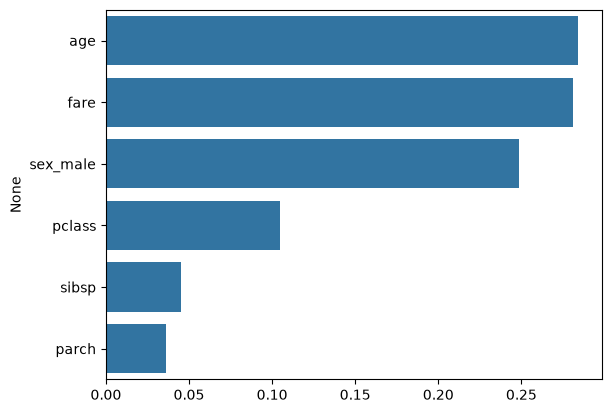

In [122]:
# visualize feature importance
import seaborn as sns

sns.barplot(x=importances[indices], y=X.columns[indices])

In [123]:
# visualize a sample decision tree from the random forest
from sklearn.tree import export_graphviz
export_graphviz(rf.estimators_[0], out_file='tree.dot', feature_names=X.columns, class_names=['Not Survived', 'Survived'], rounded=True, proportion=False, precision=2, filled=True)




[See dot file](https://graphvizonline.net)

# Unbalanced data and the issue with accuracy as a metric

$F1 \text{ score} = 2 * \frac{\text{precision} * \text{recall}}{\text{precision} + \text{recall}}$

$precision = \frac{TP}{TP + FP}$

$recall = \frac{TP}{TP + FN}$

Precision is the ratio of correctly predicted positive observations to the total predicted positive observations. It is also called Positive Predictive Value. High precision relates to the low false positive rate.

Recall (Sensitivity) is the ratio of correctly predicted positive observations to the all observations in actual class. The question recall answers is: Of all the actual positives, how many did we correctly predict?

Accuracy is the most intuitive performance measure and it is simply a ratio of correctly predicted observation to the total observations. But, accuracy is not a good measure when you have imbalanced classes. For example, if 95% of your data belongs to class A and only 5% belongs to class B, then a model that always predicts class A will have an accuracy of 95%. However, this model is useless because it fails to identify any instances of class B.